# Bianchi (2011): Overborrowing and Systemic Externalities

- Authors: Yuxuan Zhao
- Date: 2026-09-22

This notebook replicates the representative-household, stochastic small-open-economy model in [Bianchi (2011)](../reference/2011-overborrowing-and-systemic-externalities-in-the-business-cycle.pdf), *American Economic Review*, 101(7), 3400–3426.

Borrowing is denominated in tradable goods, while collateral includes nontradable income valued at an endogenous relative price. Households take this price as given. A constrained planner internalizes how precautionary saving reduces future price declines and the associated tightening of borrowing capacity.

## 1. Setup

Use a Julia 1.12 kernel. Activate the project environment and load the model functions.

In [1]:
using Pkg
project_root = let dir = abspath(pwd())
    while !isfile(joinpath(dir, "Project.toml"))
        parent = dirname(dir)
        parent == dir && error("Could not locate the project environment")
        dir = parent
    end
    dir
end
Pkg.activate(project_root)
ENV["GKSwstype"] = "100"
using LinearAlgebra, Printf, Random, Statistics, Markdown
include(joinpath(project_root, "src", "bianchi2011", "Bianchi2011.jl"))
using .Bianchi2011
include(joinpath(project_root, "src", "bianchi2011", "plots.jl"))
source = source_check(project_root)
println("Julia ", VERSION)

  Activating project at `C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_second_year\ECON8401\HA_with_Collateral_Constraint`


Julia 1.12.4


## 2. Economic environment

### 2.1 Households, goods, uncertainty, and timing

There is a unit mass of identical, infinitely lived, price-taking households. Tradable goods can be exchanged internationally; nontradable goods clear domestically. Endowments are subject to aggregate risk.

At the start of date $t$, the economy inherits bond holdings $b_t$ and observes $y_t=(y_t^T,y_t^N)$. It then chooses consumption and end-of-period bond holdings $b_{t+1}$. Next period's endowment is drawn from $\Pi(y_{t+1}\mid y_t)$.

The bond is non-state-contingent and denominated in tradable goods. Positive $b$ means assets; negative $b$ means debt. The gross world interest rate is $R=1+r$. The tradable price is normalized to one; $p_t^N$ is the nontradable price in tradable units.

### 2.2 Preferences

Households maximize
$$
\mathbb E_0\sum_{t=0}^{\infty}\beta^t
\frac{\left[\omega(c_t^T)^{-\eta}+(1-\omega)(c_t^N)^{-\eta}\right]^{(\sigma-1)/\eta}}{1-\sigma}.
$$
The elasticity of substitution between the two goods is $1/(1+\eta)$. The marginal utility of tradable consumption is
$$
u_T(c^T,c^N)
=\omega(c^T)^{-1-\eta}
\left[\omega(c^T)^{-\eta}+(1-\omega)(c^N)^{-\eta}\right]^{(\sigma-1)/\eta-1}.
$$

### 2.3 Budget and collateral constraints

The household budget constraint is
$$
c_t^T+p_t^Nc_t^N+b_{t+1}=Rb_t+y_t^T+p_t^Ny_t^N.
$$
Borrowing is limited by the market value of **current income**:
$$
b_{t+1}\geq-\left(\kappa^Ty_t^T+\kappa^Np_t^Ny_t^N\right).
$$
We set $\kappa^T=\kappa^N=\kappa$. Markets are incomplete because households trade only this bond and face the borrowing limit. The calibration satisfies $\beta R<1$.

### 2.4 Goods markets and the price feedback

In the symmetric equilibrium,
$$
c_t^N=y_t^N,\qquad c_t^T+b_{t+1}=Rb_t+y_t^T.
$$
Hence
$$
p_t^N=p(c_t^T,y_t^N)
=\frac{1-\omega}{\omega}\left(\frac{c_t^T}{y_t^N}\right)^{1+\eta}.
$$
When the borrowing constraint binds, an adverse shock can force tradable consumption down. The associated decline in $p^N$ reduces the collateral value and forces further adjustment. This price feedback operates even though each individual household treats the price as given.

## 3. Recursive problems and equilibrium

### 3.1 Household recursive problem

The individual state is $(b,B,y)$: $b$ is the household's own bond holdings, $B$ is aggregate net foreign assets, and $y=(y^T,y^N)$ is the aggregate endowment. The household takes the price function $p^N(B,y)$, the aggregate law of motion $\Gamma(B,y)$, the world return $R$, and the transition probabilities $\Pi(y'\mid y)$ as given.

Its recursive problem is

$$
\begin{aligned}
V(b,B,y)
&=\max_{c^T,c^N,b'}
\left\{\frac{\left[\omega(c^T)^{-\eta}+(1-\omega)(c^N)^{-\eta}\right]^{(\sigma-1)/\eta}}{1-\sigma}
+\beta\sum_{y'}\Pi(y'\mid y)V(b',B',y')\right\} \\
\text{subject to}\qquad
c^T+p^N(B,y)c^N+b'
&=Rb+y^T+p^N(B,y)y^N, \\
b'&\geq-\left[\kappa^Ty^T+\kappa^Np^N(B,y)y^N\right], \\
B'&=\Gamma(B,y), \\
y'&\sim\Pi(\cdot\mid y), \\
c^T&>0,\qquad c^N>0.
\end{aligned}
$$

Denote the optimal policies by

$$
\begin{aligned}
c^T&=h_T(b,B,y), & c^N&=h_N(b,B,y), & b'&=h(b,B,y).
\end{aligned}
$$

The household can change its own $b'$ and consumption, but treats both $p^N(B,y)$ and $B'=\Gamma(B,y)$ as fixed when choosing. In particular, its borrowing limit does not vary with its individual consumption choice. The condition $c^N=y^N$ will be imposed through market clearing, after defining the household problem.

### 3.2 Recursive competitive equilibrium

Given the model primitives, a **symmetric recursive competitive equilibrium** is a collection of functions

$$
\left\{V,\ h_T,\ h_N,\ h,\ p^N,\ \Gamma\right\}
$$

such that the following conditions hold.

**1. Household optimality.** Given $p^N$ and $\Gamma$, $V$ satisfies the household Bellman equation and the policies attain its maximum:

$$
\begin{aligned}
\big(h_T(b,B,y),h_N(b,B,y),h(b,B,y)\big)
&\in\operatorname*{arg\,max}_{c^T,c^N,b'}
\Big\{\frac{\left[\omega(c^T)^{-\eta}+(1-\omega)(c^N)^{-\eta}\right]^{(\sigma-1)/\eta}}{1-\sigma}
+\beta\sum_{y'}\Pi(y'\mid y)V(b',B',y')\Big\} \\
\text{subject to}\qquad
c^T+p^N(B,y)c^N+b'
&=Rb+y^T+p^N(B,y)y^N, \\
b'&\geq-\left[\kappa^Ty^T+\kappa^Np^N(B,y)y^N\right], \\
B'&=\Gamma(B,y), \\
y'&\sim\Pi(\cdot\mid y), \\
c^T&>0,\qquad c^N>0.
\end{aligned}
$$

**2. Intratemporal allocation and prices.** The nontradable price equals the household's marginal rate of substitution. At the symmetric allocation,

$$
p^N(B,y)
=\frac{1-\omega}{\omega}
\left(\frac{h_T(B,B,y)}{h_N(B,B,y)}\right)^{1+\eta},
$$

The tradable price is one and the foreign bond pays the given gross return $R$.

**3. Consistency of the aggregate law of motion.** Since households have identical endowments and the same inherited assets in the symmetric equilibrium, $b=B$. Their bond choices generate the aggregate law that they take as given:

$$
\begin{aligned}
\Gamma(B,y)&=h(B,B,y), \\
B'&=\Gamma(B,y), \\
y'&\sim\Pi(\cdot\mid y).
\end{aligned}
$$

**4. Market clearing and aggregate resources.** Nontradable consumption equals the nontradable endowment, and tradable consumption plus foreign-asset purchases equals available tradable resources:

$$
\begin{aligned}
h_N(B,B,y)&=y^N, \\
h_T(B,B,y)+\Gamma(B,y)&=RB+y^T.
\end{aligned}
$$

Foreign borrowing and lending occur at the world return $R$; aggregate net foreign assets $B$ need not be zero.

For computation, restrict the household policies to this symmetric equilibrium and write the aggregate state as $(b,y)$. Define

$$
\begin{aligned}
c^{DE}(b,y)&=h_T(b,b,y), \\
g^{DE}(b,y)&=h(b,b,y)=\Gamma(b,y), \\
p^{DE}(b,y)&=p^N(b,y)
=p\!\left(c^{DE}(b,y),y^N\right), \\
c^{DE}(b,y)+g^{DE}(b,y)&=Rb+y^T.
\end{aligned}
$$

Thus a consumption policy determines both the bond policy and the equilibrium price. This restriction to $b=B$ is taken after household optimality: each household still treats the price and aggregate law as given.

### 3.3 Competitive-equilibrium optimality conditions

Let $\lambda^{DE}$ be the household budget multiplier and $\mu^{DE}$ the collateral multiplier. In the conditions below, suppress the state arguments: unprimed quantities are evaluated at $(b,y)$ and primed quantities at $(b',y')$. Consumption $c^T$, next-period bonds $b'$, and the price $p^N$ are the equilibrium choices and price at the current state.

The equilibrium conditions are

$$
\begin{aligned}
\lambda^{DE}&=u_T(c^T,y^N), \\
\lambda^{DE}&=\beta R\sum_{y'}\Pi(y'\mid y)\lambda^{DE\prime}+\mu^{DE}, \\
c^T+b'&=Rb+y^T, \\
b'&\geq-\left[\kappa^Ty^T+\kappa^Np^Ny^N\right], \\
\mu^{DE}&\geq0, \\
\mu^{DE}\left[b'+\kappa^Ty^T+\kappa^Np^Ny^N\right]&=0.
\end{aligned}
$$

When the constraint is slack, current marginal utility equals the discounted return to saving. A positive $\mu^{DE}$ indicates a binding constraint and measures the gain from relaxing the borrowing limit; the multiplier can be zero at the switching point.

### 3.4 Constrained planner's recursive problem

The planner's state is $(B,y)$. It chooses aggregate consumption and next-period foreign assets, taking account of how aggregate consumption determines the nontradable price. Its complete recursive problem is

$$
\begin{aligned}
W(B,y)
&=\max_{c^T,c^N,B'}
\left\{\frac{\left[\omega(c^T)^{-\eta}+(1-\omega)(c^N)^{-\eta}\right]^{(\sigma-1)/\eta}}{1-\sigma}
+\beta\sum_{y'}\Pi(y'\mid y)W(B',y')\right\} \\
\text{subject to}\qquad c^T+B'&=RB+y^T, \\
c^N&=y^N, \\
B'&\geq-\left[\kappa^Ty^T+\kappa^Np(c^T,y^N)y^N\right], \\
p^N=p(c^T,y^N)&=\frac{1-\omega}{\omega}
\left(\frac{c^T}{y^N}\right)^{1+\eta}, \\
y'&\sim\Pi(\cdot\mid y), \\
c^T&>0,\qquad c^N>0.
\end{aligned}
$$

The price is implied by the competitive intratemporal allocation of goods. It is not an independently chosen instrument. The planner's bond policy gives the endogenous transition $B'=g^{SP}(B,y)$.

The same collateral rule enters the two problems with different price dependence:

$$
\begin{aligned}
\text{Household:}\qquad
b'&\geq-\left[\kappa^Ty^T+\kappa^Np^N(B,y)y^N\right],
&&p^N(B,y)\text{ is given}, \\
\text{Planner:}\qquad
B'&\geq-\left[\kappa^Ty^T+\kappa^Np(RB+y^T-B',y^N)y^N\right],
&&p^N\text{ depends on }B'.
\end{aligned}
$$

Consequently, changing aggregate consumption changes the planner's borrowing capacity, whereas an individual household takes that capacity as given at $(B,y)$.

### 3.5 Planner optimality and the externality

Substitute $c^N=y^N$ and write the planner's Lagrangian as

$$
\begin{aligned}
\mathcal L
={}&\frac{\left[\omega(c^T)^{-\eta}+(1-\omega)(y^N)^{-\eta}\right]^{(\sigma-1)/\eta}}{1-\sigma}
+\beta\sum_{y'}\Pi(y'\mid y)W(B',y') \\
&+\lambda^{SP}(RB+y^T-c^T-B') \\
&+\mu^{SP}\left[B'+\kappa^Ty^T+\kappa^Np(c^T,y^N)y^N\right].
\end{aligned}
$$

Define the marginal collateral-price effect

$$
\Psi
=\kappa^Ny^N\frac{\partial p(c^T,y^N)}{\partial c^T}
=\kappa^N(1+\eta)\frac{p(c^T,y^N)y^N}{c^T}.
$$

The first-order and envelope conditions are

$$
\begin{aligned}
\frac{\partial\mathcal L}{\partial c^T}=0
&\quad\Longrightarrow\quad
\lambda^{SP}=u_T(c^T,y^N)+\mu^{SP}\Psi, \\
\frac{\partial\mathcal L}{\partial B'}=0
&\quad\Longrightarrow\quad
\lambda^{SP}=\beta\sum_{y'}\Pi(y'\mid y)W_B(B',y')+\mu^{SP}, \\
W_B(B,y)&=R\lambda^{SP}.
\end{aligned}
$$

Again write the aggregate state as $(b,y)$. Suppress state arguments in the conditions below: unprimed quantities are evaluated at $(b,y)$ and primed quantities at $(b',y')$. Here $c^T$ and $b'$ are the planner's consumption and bond choices, and $p^N=p(c^T,y^N)$ is the implied price.

The recursive optimality conditions become

$$
\begin{aligned}
\lambda^{SP}&=u_T(c^T,y^N)+\mu^{SP}\Psi, \\
\lambda^{SP}&=\beta R\sum_{y'}\Pi(y'\mid y)\lambda^{SP\prime}+\mu^{SP}, \\
c^T+b'&=Rb+y^T, \\
b'&\geq-\left[\kappa^Ty^T+\kappa^Np^Ny^N\right], \\
\mu^{SP}&\geq0, \\
\mu^{SP}\left[b'+\kappa^Ty^T+\kappa^Np^Ny^N\right]&=0.
\end{aligned}
$$

Combining the first two equations gives

$$
u_T(c^T,y^N)+\mu^{SP}\Psi
=\beta R\sum_{y'}\Pi(y'\mid y)
\left[u_T(c^{T\prime},y^{N\prime})+\mu^{SP\prime}\Psi'\right]
+\mu^{SP}.
$$

When the current constraint is slack, $\mu^{SP}=0$, but future multipliers can be positive. The planner therefore takes account of the additional marginal value of saving

$$
\beta R\sum_{y'}\Pi(y'\mid y)\mu^{SP\prime}\Psi'.
$$

At a binding solution, write $M^{SP}=\beta R\sum_{y'}\Pi(y'\mid y)\lambda^{SP\prime}$. The same conditions imply

$$
\mu^{SP}
=\frac{u_T(c^T,y^N)-M^{SP}}{1-\Psi}
\qquad\text{when }\Psi<1.
$$

This is an identity at the solution. The numerical algorithm below updates the multiplier by iterating $\mu=\lambda-M^{SP}$ together with consumption and prices.

## 4. Calibration

A period is one year. The calibration uses Argentina's annual data for 1965-2007.

### 4.1 Structural parameters

| Parameter | Value | Basis or calibration target |
| --- | --- | --- |
| Relative risk aversion | $\sigma=2$ | Standard benchmark |
| World net interest rate | $r=0.04$ | Annual risk-free return; $R=1.04$ |
| T/N substitution elasticity | $1/(1+\eta)=0.83$ | Upper end of the empirical range; $\eta\approx0.20482$ |
| Tradable CES weight | $\omega=0.3070$ | Tradable production accounts for $32\%$ of output value |
| Discount factor | $\beta=0.906$ | Average net foreign assets relative to GDP: $-29\%$ |
| Collateral coefficients | $\kappa^T=\kappa^N=0.3235$ | Sudden-stop frequency: $5.5\%$; equal coefficients in the baseline |

The last three parameters are chosen jointly to match long-run moments of the decentralized equilibrium. In particular, $\omega$ is a preference weight, not the observed tradable-output share itself: prices and consumption determine that share in equilibrium. The sudden-stop target requires both a binding borrowing constraint and a sufficiently large net capital outflow, as defined in the simulation section.

### 4.2 Joint endowment states and transition probabilities

The HP-filtered log cyclical components of tradable and nontradable output are fitted jointly with a VAR(1). Tradables comprise manufacturing and primary products; nontradables comprise the remaining sectors. The estimated process is

$$
\begin{pmatrix}\log y^{T\prime}\\\log y^{N\prime}\end{pmatrix}
=
\begin{pmatrix}0.901&0.495\\-0.453&0.225\end{pmatrix}
\begin{pmatrix}\log y^T\\\log y^N\end{pmatrix}
+
\begin{pmatrix}\varepsilon^{T\prime}\\\varepsilon^{N\prime}\end{pmatrix},
$$

$$
\begin{pmatrix}\varepsilon^{T\prime}\\\varepsilon^{N\prime}\end{pmatrix}
\sim\mathcal N\!\left(
\begin{pmatrix}0\\0\end{pmatrix},
\begin{pmatrix}0.00219&0.00162\\0.00162&0.00167\end{pmatrix}
\right).
$$

A Tauchen-Hussey quadrature approximation with four nodes per shock dimension gives 16 joint endowment states:

$$
y_j=(y_j^T,y_j^N),\qquad j=1,\ldots,16.
$$

The $16\times16$ transition matrix records the conditional probabilities

$$
\Pr(y'=y_\ell\mid y=y_j)\geq0,
\qquad
\sum_{\ell=1}^{16}\Pr(y'=y_\ell\mid y=y_j)=1
\quad\text{for every }j.
$$

The stationary probabilities reported below satisfy

$$
\begin{aligned}
\Pr_{\mathrm{stat}}(y=y_\ell)
&=\sum_{j=1}^{16}
\Pr(y'=y_\ell\mid y=y_j)\Pr_{\mathrm{stat}}(y=y_j),\\
\sum_{j=1}^{16}\Pr_{\mathrm{stat}}(y=y_j)&=1.
\end{aligned}
$$

Endowment levels are normalized to have unit stationary means:

$$
\mathbb E_{\mathrm{stat}}[y^T]
=\mathbb E_{\mathrm{stat}}[y^N]=1.
$$

### 4.3 Bond units and numerical grid

Bonds are denominated in tradable goods. With $\mathbb E_{\mathrm{stat}}[y^T]=1$, their unit is average annual tradable endowment. The sign convention and the net-foreign-asset ratio are

$$
\begin{aligned}
b>0&:\ \text{net foreign assets},\qquad
b<0:\ \text{net foreign debt},\\
\text{NFA/GDP}&=\frac{b}{y^T+p^Ny^N}.
\end{aligned}
$$

Use 800 equally spaced bond points on

$$
b\in[-1.02,-0.20],\qquad N_b=800.
$$

This negative interval covers borrowing states relevant to the benchmark calibration. Its endpoints are numerical truncations; the economic borrowing constraint remains

$$
b'\geq-\left[\kappa^Ty^T+\kappa^Np^Ny^N\right].
$$

Grid resolution is checked using 400, 800, and 1,600 points on the same interval. Simulated endpoint use is checked separately.

In [2]:
params = parameters()
NB = 800
T_SIM = 80_000
BURN = 5_000
SEED = 2011
m = model(; nb=NB, p=params)
pi_y = stationary_shocks(m)
display(MIME"text/html"(), Markdown.parse(markdown_table(["Joint state", "Tradable endowment", "Nontradable endowment", "Stationary probability"],
    [(s, m.yT[s], m.yN[s], pi_y[s]) for s in 1:m.ns]; digits=5)))
@assert maximum(abs.(sum(m.Pi, dims=2) .- 1)) < 1e-12
@assert minimum(m.Pi) >= 0
@assert params.beta*params.R < 1

Joint state,Tradable endowment,Nontradable endowment,Stationary probability
1,0.89073,0.86718,0.01916
2,0.96527,0.92239,0.06472
3,1.03473,0.97384,0.04881
4,1.10927,1.02905,0.00782
5,0.89073,0.90258,0.03790
6,0.96527,0.95779,0.15165
7,1.03473,1.00923,0.14043
8,1.10927,1.06444,0.02950
9,0.89073,0.93556,0.02950
10,0.96527,0.99077,0.14043


## 5. Numerical algorithms

### 5.1 Iteration structure

On the grid in Section 4, iterate the consumption policy for DE and the consumption and multiplier policies for the planner. Bonds and prices follow from

$$
g^{(k)}=Rb+y^T-c^{(k)},\qquad
p^{N,(k)}=\frac{1-\omega}{\omega}
\left(\frac{c^{(k)}}{y^N}\right)^{1+\eta}.
$$

The outer iteration $k$ updates the full policy tables. Within each state, hold the old policies fixed, compute expected marginal value and the borrowing bound, and solve for consumption. Store undamped choices with a tilde and update the old tables only after visiting all states. State arguments are omitted except where needed to specify future-policy evaluations.

### 5.2 Decentralized equilibrium

Initialize

$$
g^{(0)}=b,\qquad c^{(0)}=(R-1)b+y^T,
$$

with prices implied by Section 5.1. Repeat the following four steps.

**1. Expected marginal utility.** At current state $(b,y_j)$, evaluate future marginal utility at the old bond choice:

$$
\begin{aligned}
M^{(k)}
={}&\beta R\sum_{\ell=1}^{16}
\Pr(y'=y_\ell\mid y=y_j)\\
&\quad\times\mathcal I_b\!\left[
u_T(c^{(k)}(\cdot,y_\ell),y_\ell^N)
\right]\!\left(g^{(k)}\right).
\end{aligned}
$$

Here $\mathcal I_b$ linearly interpolates the marginal-utility values on the bond grid. Keep $M^{(k)}$ fixed throughout the inner consumption calculation; the updated bond choice enters the expectation in the next outer iteration.

**2. Temporary borrowing bound.** Using the old price, calculate

$$
\begin{aligned}
\underline b^{(k)}
&=\min\!\left\{b_{\max},
\max\!\left\{b_{\min},-\kappa^Ty^T-\kappa^Np^{N,(k)}y^N\right\}\right\},\\
c_{\mathrm{bound}}^{(k)}&=Rb+y^T-\underline b^{(k)},\\
c_{\min}&=Rb+y^T-b_{\max}.
\end{aligned}
$$

This algebraic bound is recomputed every outer iteration as prices change.

**3. Consumption and bonds.** Choose

$$
\widetilde c=
\begin{cases}
c_{\mathrm{bound}}^{(k)},
&u_T(c_{\mathrm{bound}}^{(k)},y^N)\geq M^{(k)},\\
c_{\min},
&u_T(c_{\min},y^N)\leq M^{(k)},\\
x\text{ satisfying }u_T(x,y^N)=M^{(k)},
&\text{otherwise},
\end{cases}
\qquad
\widetilde g=Rb+y^T-\widetilde c.
$$

The first branch reaches the borrowing bound; the second reaches the numerical saving endpoint. For an interior choice, solve the scalar Euler equation with Brent's method on $[c_{\min},c_{\mathrm{bound}}^{(k)}]$.

**4. Update and convergence.** After the full grid sweep, damp consumption:

$$
c^{(k+1)}=0.8c^{(k)}+0.2\widetilde c.
$$

Recover $g^{(k+1)}$ and $p^{N,(k+1)}$ from Section 5.1. Stop when the undamped changes satisfy

$$
\max\!\left\{
\|\widetilde c-c^{(k)}\|_\infty,
\|\widetilde g-g^{(k)}\|_\infty
\right\}<10^{-11};
$$

otherwise return to Step 1 with the updated policies.

### 5.3 Constrained planner

The outer iteration updates the planner's consumption and multiplier policies. Initialize consumption at the converged DE policy and the multiplier at zero:

$$
\begin{aligned}
c^{(0)}&=c^{DE}, &\mu^{(0)}&=0,\\
g^{(0)}&=Rb+y^T-c^{(0)}, &
p^{N,(0)}&=\frac{1-\omega}{\omega}
\left(\frac{c^{(0)}}{y^N}\right)^{1+\eta}.
\end{aligned}
$$

At iteration $k$, hold these old policy tables fixed during the inner calculation at each state. Repeat the following four steps.

**1. Expected marginal value.** Calculate the old collateral-price effect and marginal value of resources:

$$
\Psi^{(k)}=\kappa^N(1+\eta)\frac{p^{N,(k)}y^N}{c^{(k)}},
\qquad
\lambda^{(k)}=u_T(c^{(k)},y^N)+\mu^{(k)}\Psi^{(k)}.
$$

At current state $(b,y_j)$, evaluate the expectation at the old bond choice:

$$
\begin{aligned}
M_{SP}^{(k)}
={}&\beta R\sum_{\ell=1}^{16}
\Pr(y'=y_\ell\mid y=y_j)\\
&\quad\times\mathcal I_b\!\left[
u_T(c^{(k)}(\cdot,y_\ell),y_\ell^N)
+\mu^{(k)}(\cdot,y_\ell)\Psi^{(k)}(\cdot,y_\ell)
\right]\!\left(g^{(k)}\right).
\end{aligned}
$$

Linearly interpolate the marginal-value table on the bond grid. Keep $M_{SP}^{(k)}$ fixed during the inner consumption calculation; it includes future collateral effects even when the current constraint is slack.

**2. Temporary borrowing bound.** Using the old price, calculate

$$
\begin{aligned}
\underline b^{(k)}
&=\min\!\left\{b_{\max},
\max\!\left\{b_{\min},-\kappa^Ty^T-\kappa^Np^{N,(k)}y^N\right\}\right\},\\
c_{\mathrm{bound}}^{(k)}&=Rb+y^T-\underline b^{(k)},\\
c_{\min}&=Rb+y^T-b_{\max}.
\end{aligned}
$$

Recompute this algebraic bound every outer iteration as prices change.

**3. Consumption, bonds, and multiplier.** On the economically relevant branch $\Psi<1$, choose

$$
\widetilde c=
\begin{cases}
c_{\mathrm{bound}}^{(k)},
&u_T(c_{\mathrm{bound}}^{(k)},y^N)\geq M_{SP}^{(k)},\\
c_{\min},
&u_T(c_{\min},y^N)\leq M_{SP}^{(k)},\\
x\text{ satisfying }u_T(x,y^N)=M_{SP}^{(k)},
&\text{otherwise},
\end{cases}
\qquad
\widetilde g=Rb+y^T-\widetilde c.
$$

Solve an interior choice with Brent's method on $[c_{\min},c_{\mathrm{bound}}^{(k)}]$. On the borrowing-bound branch, if the economic limit lies strictly inside the numerical grid,

$$
b_{\min}<-\kappa^Ty^T-\kappa^Np^{N,(k)}y^N<b_{\max},
$$

update the collateral multiplier by

$$
\widetilde\mu=\max\!\left\{0,\lambda^{(k)}-M_{SP}^{(k)}\right\}.
$$

Set $\widetilde\mu=0$ for all other branches, including numerical grid bounds. This update uses the old $\lambda^{(k)}$; the formula $\mu=(u_T-M_{SP})/(1-\Psi)$ in Section 3.5 holds at convergence.

**4. Update and convergence.** After collecting choices at every state, update

$$
\begin{aligned}
c^{(k+1)}&=0.995c^{(k)}+0.005\widetilde c,\\
\mu^{(k+1)}&=\widetilde\mu,\\
g^{(k+1)}&=Rb+y^T-c^{(k+1)},\\
p^{N,(k+1)}&=\frac{1-\omega}{\omega}
\left(\frac{c^{(k+1)}}{y^N}\right)^{1+\eta}.
\end{aligned}
$$

Stop when the undamped changes satisfy

$$
\max\!\left\{
\|\widetilde c-c^{(k)}\|_\infty,
\|\widetilde g-g^{(k)}\|_\infty,
\|\widetilde\mu-\mu^{(k)}\|_\infty
\right\}<10^{-11};
$$

otherwise return to Step 1 with the updated policies, recomputing marginal values, expectations, and borrowing bounds.

For both equilibria, verify resource balance, the price equation, collateral feasibility, Euler conditions, multiplier nonnegativity, and complementary slackness at convergence.

### 5.4 Value evaluation

For each converged policy, hold consumption and bonds fixed. Initialize its value function at current utility divided by $1-\beta$:

$$
V_0(b,y)=
\frac{\left[\omega(c(b,y))^{-\eta}+(1-\omega)(y^N)^{-\eta}\right]^{(\sigma-1)/\eta}}
{(1-\sigma)(1-\beta)}.
$$

Then iterate

$$
\begin{aligned}
V_{n+1}(b,y_j)
={}&\frac{\left[\omega(c(b,y_j))^{-\eta}+(1-\omega)(y_j^N)^{-\eta}\right]^{(\sigma-1)/\eta}}{1-\sigma}\\
&+\beta\sum_{\ell=1}^{16}\Pr(y'=y_\ell\mid y=y_j)
\mathcal I_b[V_n(\cdot,y_\ell)]\!\left(g(b,y_j)\right)
\end{aligned}
$$

until $\|V_{n+1}-V_n\|_\infty<2\times10^{-11}$. This gives the DE and planner welfare values without updating their policies.

In [3]:
de_seconds = @elapsed de = solve_de(m)
sp_seconds = @elapsed sp = solve_planner(m; initial=de.g)
de_check = diagnostics(m, de)
sp_check = diagnostics(m, sp)
display(MIME"text/html"(), Markdown.parse(markdown_table(
    ["Solution", "Iterations", "Seconds", "Stopping residual"],
    [("DE: Euler time iteration", de.iterations, de_seconds, @sprintf("%.3e", de.error)),
     ("SP: Euler / multiplier iteration", sp.iterations, sp_seconds, @sprintf("%.3e", sp.error))])))
@assert de_check.budget_error < 1e-12
@assert sp_check.budget_error < 1e-12
@assert min(de_check.min_collateral_slack, sp_check.min_collateral_slack) > -1e-10
@assert de_check.max_interior_euler < 1e-7
@assert de_check.binding_inequality_violation < 1e-8
@assert minimum(sp.g-de.g) > -1e-7
@assert sp_check.max_euler_residual < 1e-8
@assert sp_check.min_multiplier >= 0
@assert sp_check.max_complementarity < 1e-8
@assert max(de_check.psi_max, sp_check.psi_max) < 1

Solution,Iterations,Seconds,Stopping residual
DE: Euler time iteration,847,17.933,9.979e-12
SP: Euler / multiplier iteration,5566,112.859,9.969e-12


## 6. Policy functions and the overborrowing mechanism

The figure compares DE (orange, solid) and SP (blue, dashed) at shock state 6. In the highly indebted region both economies borrow at the collateral limit. Where the planner takes precautions, its $b'$ is higher, meaning less borrowing. The 45-degree line identifies net saving versus borrowing.

The figure also shows the equilibrium collateral price. This is a state-by-state comparison, holding inherited debt and endowments fixed; the two economies' long-run distributions will differ.

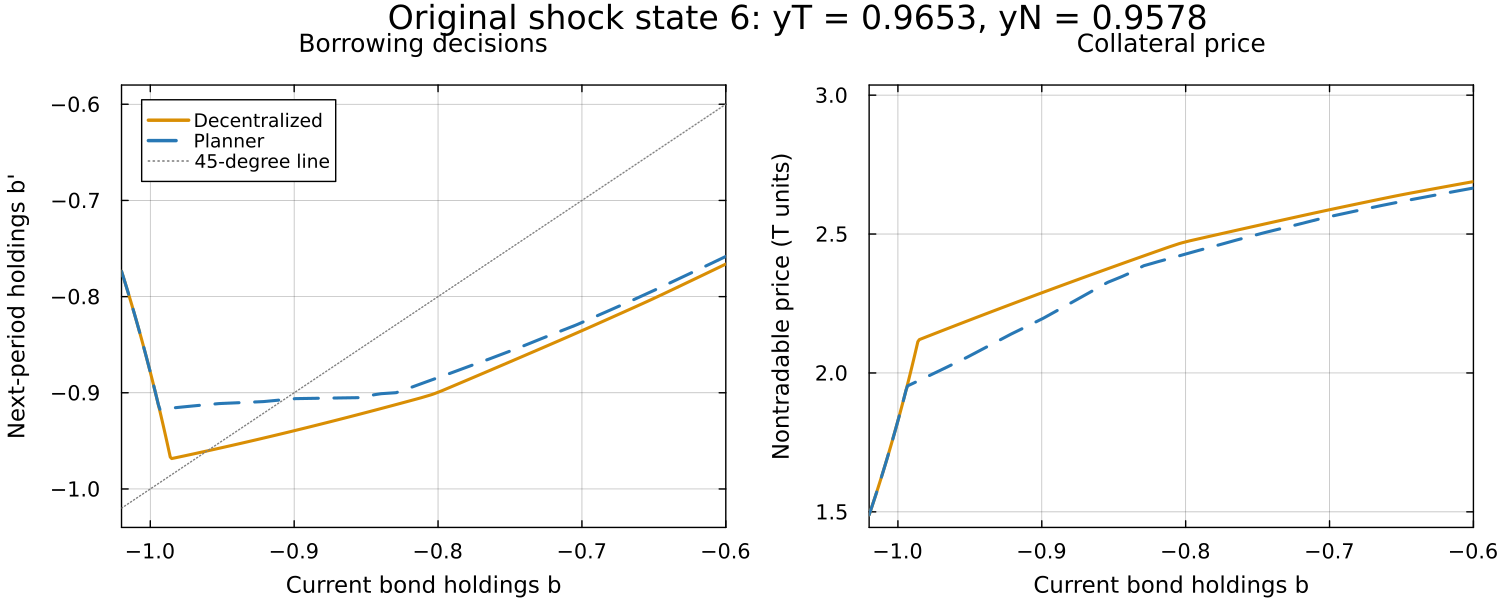

In [4]:
fig_policy = policy_figure(m, de, sp)
save_figure(fig_policy, project_root, "01_policies")

## 7. Simulation and results

### 7.1 Simulation design and crisis definition

Simulate both economies with the **same sequence of aggregate shocks**, seed 2011, 5,000 burn-in periods, and 80,000 retained periods. Each economy follows its own bond policy and therefore develops its own asset history.

Between grid points, linearly interpolate the converged bond policy, then calculate consumption from the budget and the price from market clearing. Classify the collateral constraint as binding when its slack is below $10^{-5}$. Report interpolation errors and check finer grids below.

Define nominal GDP in tradable units, net capital outflows, and the trade balance as
$$
Y_t=y_t^T+p_t^Ny_t^N,\qquad CA_t=b_{t+1}-b_t,\qquad TB_t=y_t^T-c_t^T.
$$
A crisis at date $t$ occurs if the **date-$t$ choice** $b_{t+1}$ is at the collateral limit and
$$
CA_t>\overline{CA}^{DE}+\operatorname{sd}(CA^{DE}).
$$
Both economies use the DE threshold. A binding constraint alone does not constitute a crisis.

Define the real exchange rate using the domestic CES price index in tradable units,
$$
P(p^N)=\left[\omega^{1/(1+\eta)}+(1-\omega)^{1/(1+\eta)}(p^N)^{\eta/(1+\eta)}\right]^{(1+\eta)/\eta}.
$$
A fall in $P$ is a real depreciation. We report depreciation as minus the percentage deviation of $P$ from its own ergodic mean.

In [5]:
wt = welfare_and_tax(m, de, sp)
pair = simulate_pair(m, de, sp; T=T_SIM, burn=BURN, seed=SEED)
summary = summarize(m, pair, wt)
event = event_study(m, de, sp, pair)
rows = comparison_rows(summary, event)
@printf("Crisis events: DE %d / %d; SP %d / %d\n",
    summary.crisis_count_de, T_SIM, summary.crisis_count_sp, T_SIM)
@printf("Common crisis threshold: net outflows > %.6f\n", pair.threshold)
@assert summary.min_slack > -1e-5  # interpolation error below the simulation binding tolerance
@assert summary.grid_edge_share_de == 0 && summary.grid_edge_share_sp == 0
display(MIME"text/html"(), Markdown.parse(markdown_table(
    ["Statistic", "Paper DE", "Paper SP", "Julia DE", "Julia SP"], rows[1:10])))

Crisis events: DE 4247 / 80000; SP 298 / 80000
Common crisis threshold: net outflows > 0.064821


Statistic,Paper DE,Paper SP,Julia DE,Julia SP
Crisis probability (%),5.500,0.400,5.309,0.372
Mean debt / GDP (%),29.200,28.600,29.535,28.679
Consumption std. (%),5.900,5.300,5.971,5.276
Real exchange rate std. (%),7.500,3.400,7.517,3.425
CA / GDP std. (pp),2.800,0.600,2.785,0.597
TB / GDP std. (pp),2.900,0.600,2.930,0.620
"corr(consumption, GDP)",0.830,0.860,0.836,0.855
"corr(real exchange rate, GDP)",0.790,0.440,0.792,0.436
"corr(CA / GDP, GDP)",-0.760,-0.050,-0.758,-0.064
"corr(TB / GDP, GDP)",-0.770,-0.160,-0.770,-0.174


Reported consumption and exchange-rate standard deviations use percentage deviations from their own long-run means. CA/GDP and TB/GDP standard deviations are percentage points. Correlations use GDP in tradable units. The debt statistic is the time average of $-100b_t/Y_t$.

The planner's crisis frequency falls sharply even though average debt changes comparatively little. The next figure compares the entire distribution, including its highly indebted left tail. Both densities use common bins and integrate to one.

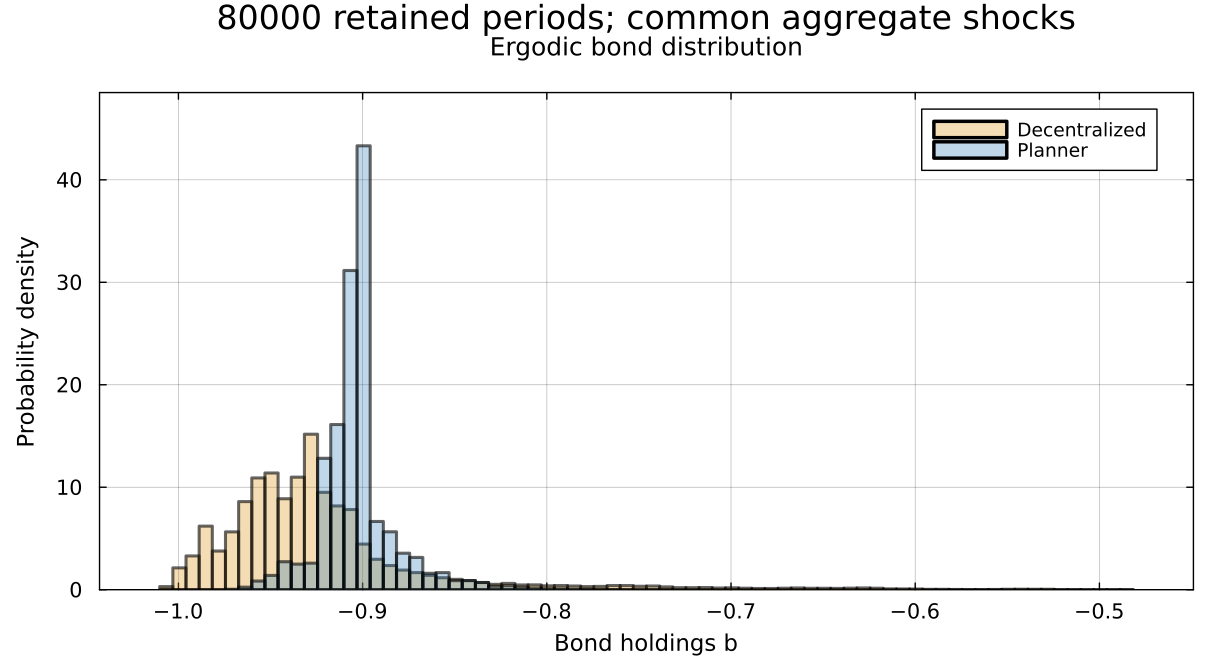

In [6]:
fig_distribution = distribution_figure(pair)
save_figure(fig_distribution, project_root, "02_bond_distribution")

### 7.2 Welfare gains and macroprudential instruments

Evaluate the final policies using the same period utility:
$$
V^q(b,y)=\frac{\left[\omega(c^q(b,y))^{-\eta}+(1-\omega)(y^N)^{-\eta}\right]^{(\sigma-1)/\eta}}{1-\sigma}+\beta\mathbb E V^q(g^q(b,y),y'),\qquad q\in\{DE,SP\}.
$$
The consumption-equivalent welfare gain from switching at a common initial state is
$$
\gamma(b,y)=\left[\frac{V^{SP}(b,y)}{V^{DE}(b,y)}\right]^{1/(1-\sigma)}-1.
$$
This includes the initial cost of saving more; it is not a comparison of unconditional mean utility alone. Average $\gamma$ over the DE ergodic distribution.

When the planner's constraint is slack, the effective debt tax is
$$
\tau(b,y)=\frac{u_T(c^{SP}(b,y),y^N)}{\beta R\mathbb E[u_T(c^{SP}(g^{SP}(b,y),y'),y'^N)]}-1.
$$
Set it to zero when the planner's collateral constraint binds. Average the tax over the SP ergodic distribution. The associated quantity instrument is
$$
\theta(b,y)=1+\frac{g^{SP}(b,y)}{\kappa^Ty^T+\kappa^Np^{SP}(b,y)y^N}.
$$

Statistic,Paper,Julia
Average welfare gain (% permanent consumption),0.1350,0.1347
Average effective debt tax (%),5.0000,4.9828


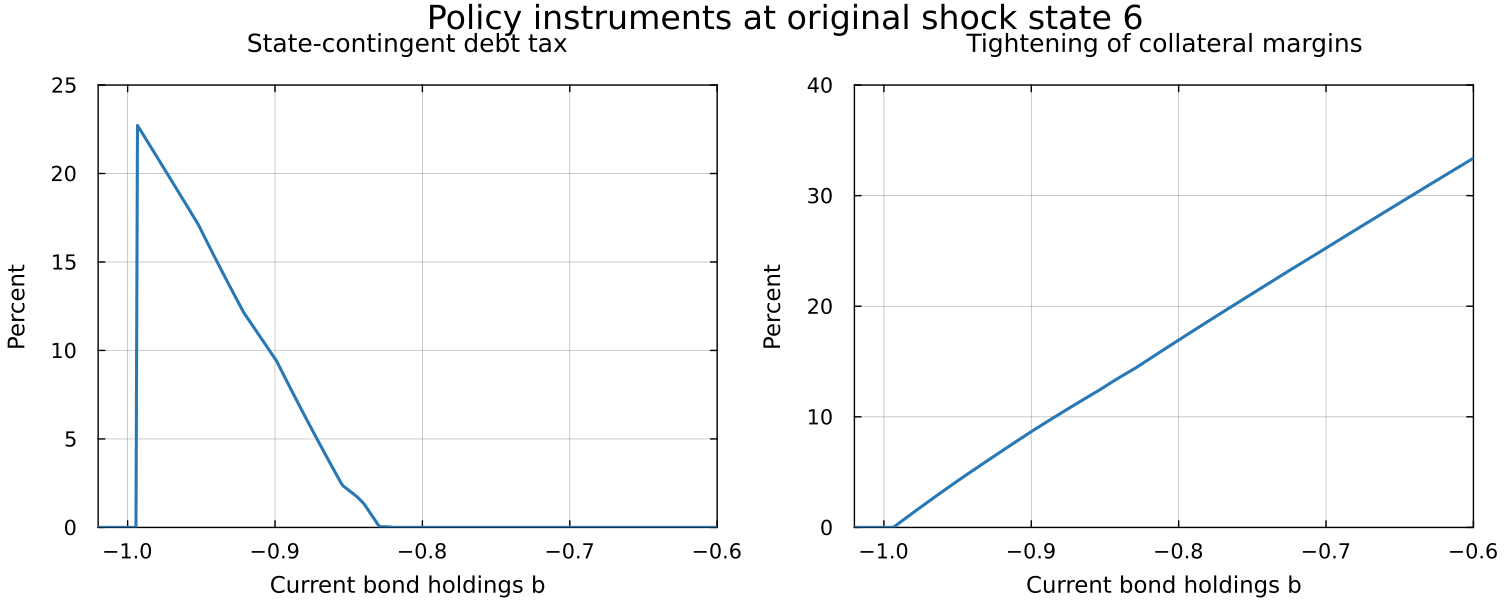

In [7]:
scalar_rows = [
    ("Average welfare gain (% permanent consumption)", 0.135, summary.welfare),
    ("Average effective debt tax (%)", 5.0, summary.tax),
]
display(MIME"text/html"(), Markdown.parse(markdown_table(["Statistic", "Paper", "Julia"], scalar_rows; digits=4)))
@assert minimum(wt.welfare) > -1e-7
fig_instruments = instruments_figure(m, sp, wt)
save_figure(fig_instruments, project_root, "03_policy_instruments")

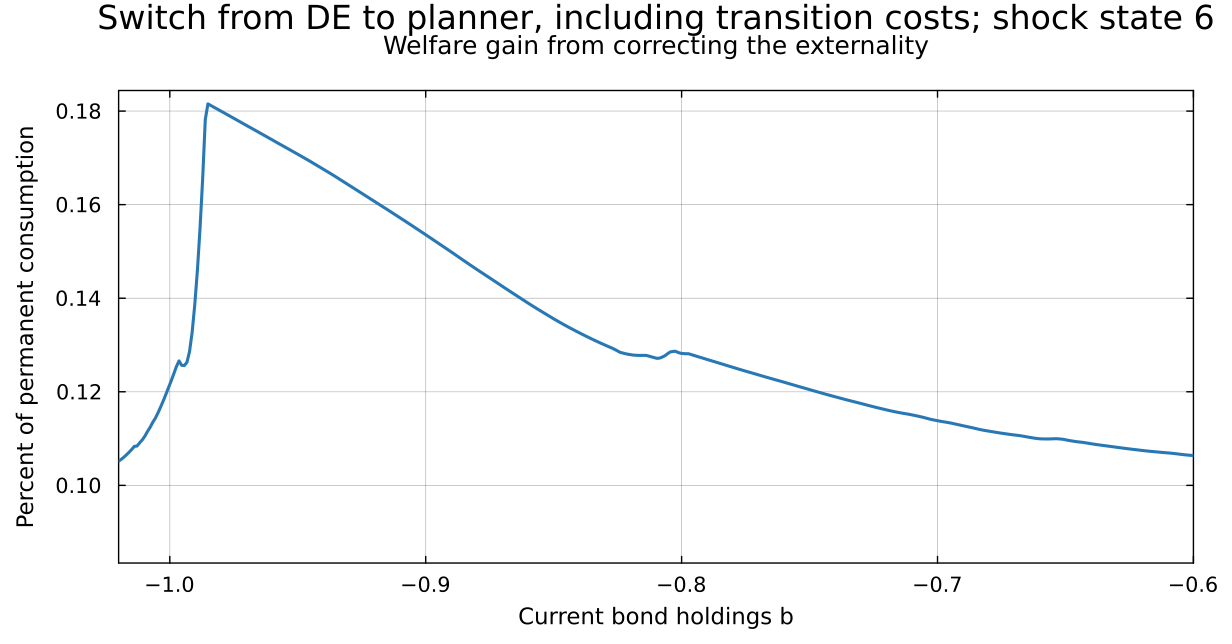

In [8]:
fig_welfare = welfare_figure(m, wt)
save_figure(fig_welfare, project_root, "04_welfare")

### 7.3 Crisis consumption distributions

Each distribution conditions on its economy's own crisis episodes. The event counts show the smaller SP crisis sample. Both densities use the same bins and integrate to one. The next exercise instead compares the economies during a common crisis episode.

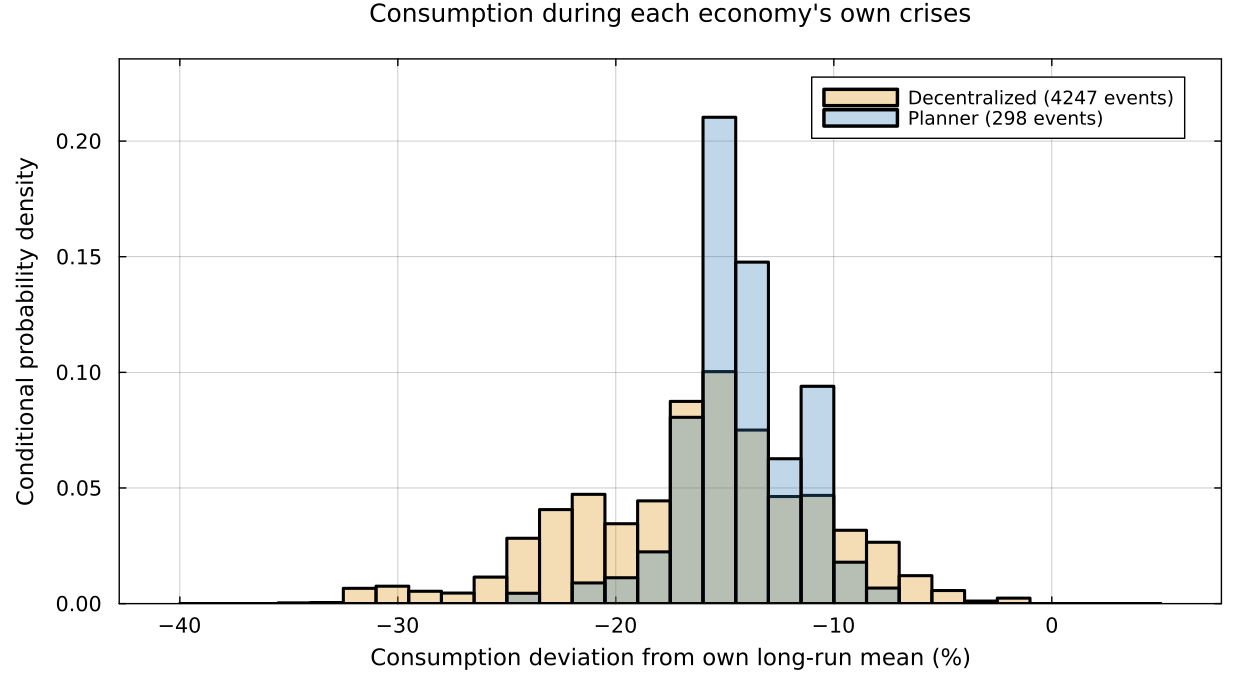

In [9]:
fig_crisis_distribution = crisis_distribution_figure(pair)
save_figure(fig_crisis_distribution, project_root, "05_crisis_consumption")

### 7.4 Median-crisis counterfactual

Construct a matched-crisis comparison:

1. Order DE crisis episodes by their net capital outflow $CA_t$ and select the median episode.
2. Record DE debt at $t-2$ and the realized endowment sequence.
3. Restart both decision rules at that **same inherited debt**, feeding in the same shocks from $t-2$ onward.
4. Compare date-$t$ outcomes, normalizing consumption and the exchange rate by each economy's own long-run mean.

Because a single episode is selected, this table is more sensitive to the simulated sample than unconditional moments. The 49th/50th/51st-percentile comparison below illustrates how similar crisis outflows can be preceded by different debt and shock histories; it is not a confidence interval or an alternative choice of the headline event.

Selected DE crisis at retained date 18138; median net outflow 0.179185


Impact statistic,Paper DE,Paper SP,Julia DE,Julia SP
Median-crisis consumption (%),-16.700,-10.100,-16.553,-10.040
Median-crisis CA / GDP (%),7.800,0.000,7.708,-0.167
Median-crisis depreciation (%),19.200,1.100,18.954,1.085


Outflow percentile,Date,Debt state at -2,DE consumption %,SP consumption %,DE CA/GDP %,SP CA/GDP %,DE depreciation %,SP depreciation %
49.000,51545,-0.920,-14.410,-8.001,7.644,0.065,21.105,4.595
50.000,18138,-0.946,-16.553,-10.040,7.708,-0.167,18.954,1.085
51.000,7911,-0.967,-14.571,-8.254,7.846,0.336,21.481,5.291


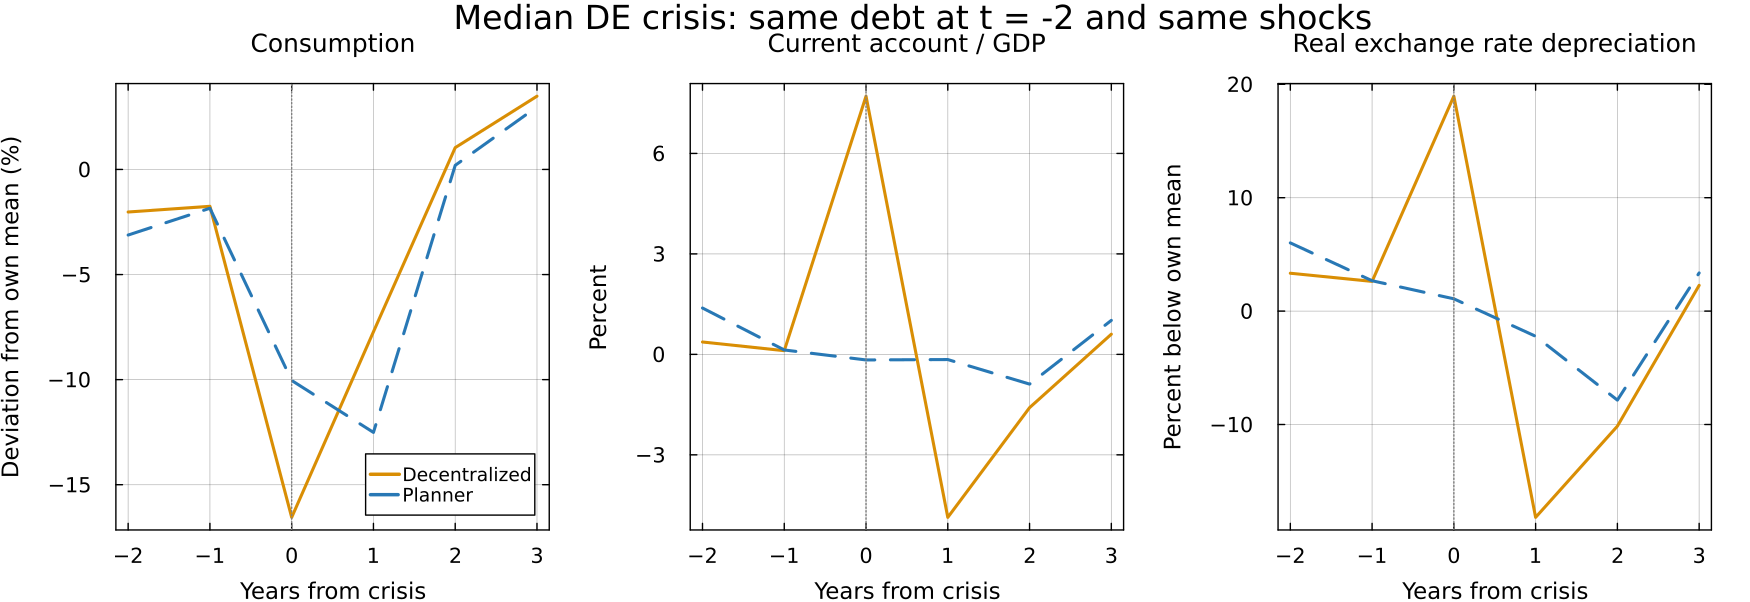

In [10]:
@printf("Selected DE crisis at retained date %d; median net outflow %.6f\n", event.tstar, event.median_CA)
@assert event.de.b[1] == event.sp.b[1]
@assert event.de.states == event.sp.states
display(MIME"text/html"(), Markdown.parse(markdown_table(
    ["Impact statistic", "Paper DE", "Paper SP", "Julia DE", "Julia SP"], rows[11:13])))
event_sensitivity = Tuple[]
for q in (0.49, 0.50, 0.51)
    ev = event_study(m, de, sp, pair; event_quantile=q)
    push!(event_sensitivity, (100q, ev.tstar, ev.de.b[1],
        ev.impact_de.consumption, ev.impact_sp.consumption,
        ev.impact_de.current_account, ev.impact_sp.current_account,
        ev.impact_de.depreciation, ev.impact_sp.depreciation))
end
display(MIME"text/html"(), Markdown.parse(markdown_table(
    ["Outflow percentile", "Date", "Debt state at -2", "DE consumption %", "SP consumption %", "DE CA/GDP %", "SP CA/GDP %", "DE depreciation %", "SP depreciation %"],
    event_sensitivity)))
fig_event = event_figure(event, pair)
save_figure(fig_event, project_root, "06_median_crisis")

## 8. Numerical validation

### 8.1 Equilibrium residuals and interpolation errors

Check budget balance, collateral feasibility, DE Euler equalities and inequalities, and the planner's Euler equation and complementary slackness. Recompute the expectations from the final policies. Also check the analytical derivatives $u_T$ and $\Psi$ against finite differences.

At every bond-grid midpoint in all 16 shock states, independently recompute DE Euler errors using future consumption and marginal utility. Linear interpolation can create small collateral violations and larger Euler errors near a binding/interior switch. Report these errors separately from the grid-point residuals and examine how they change with grid refinement.

In [11]:
derivative_check = derivative_checks(m)
offgrid = offgrid_diagnostics(m, de)
validation_rows = [
    ("Budget residual: DE", de_check.budget_error),
    ("Budget residual: SP", sp_check.budget_error),
    ("Minimum collateral slack: DE", de_check.min_collateral_slack),
    ("Minimum collateral slack: SP", sp_check.min_collateral_slack),
    ("DE grid interior relative Euler error", de_check.max_interior_euler),
    ("DE grid binding inequality violation", de_check.binding_inequality_violation),
    ("SP grid relative Euler residual", sp_check.max_euler_residual),
    ("SP complementarity residual", sp_check.max_complementarity),
    ("SP minimum multiplier", sp_check.min_multiplier),
    ("DE off-grid max relative Euler error", offgrid.maximum),
    ("DE off-grid 99th percentile error", offgrid.p99),
    ("DE off-grid binding inequality violation", offgrid.binding_violation),
    ("DE off-grid minimum collateral slack", offgrid.min_slack),
    ("Simulation minimum collateral slack", summary.min_slack),
    ("Analytical uT: finite-difference relative error", derivative_check.marginal_utility_relative_error),
    ("Analytical Psi: finite-difference relative error", derivative_check.collateral_derivative_relative_error),
]
display(MIME"text/html"(), Markdown.parse(markdown_table(["Check", "Value"],
    [(name, @sprintf("%.3e", value)) for (name, value) in validation_rows])))
@assert derivative_check.marginal_utility_relative_error < 1e-7
@assert derivative_check.collateral_derivative_relative_error < 1e-7
@assert offgrid.binding_violation < 1e-6

Check,Value
Budget residual: DE,1.110e-16
Budget residual: SP,1.110e-16
Minimum collateral slack: DE,-1.725e-12
Minimum collateral slack: SP,-3.708e-14
DE grid interior relative Euler error,8.379e-13
DE grid binding inequality violation,0.000e+00
SP grid relative Euler residual,1.150e-11
SP complementarity residual,6.716e-14
SP minimum multiplier,0.000e+00
DE off-grid max relative Euler error,3.328e-02


### 8.2 Bond-grid refinement

Re-solve both equilibria on 400 and 1,600 points, using identical parameters, shock matrix, asset interval, seed, and simulation length. Report policy distances relative to the 1,600-point solution, separately from the convergence of the outer iteration. The asset range is held fixed and its simulated boundary use is checked separately.

Rare-event frequencies need not vary monotonically with the grid. Their interpretation uses both this table and the longer simulations below. The average tax can converge more slowly because it is derived from marginal conditions close to a switching boundary.

In [12]:
grid_runs = Dict{Int,Any}(NB => (; m, de, sp, summary, offgrid))
for nb in (400, 1600)
    mg = model(; nb, p=params)
    deg = solve_de(mg)
    spg = solve_planner(mg; initial=deg.g)
    wtg = welfare_and_tax(mg, deg, spg)
    pg = simulate_pair(mg, deg, spg; T=T_SIM, burn=BURN, seed=SEED)
    sg = summarize(mg, pg, wtg)
    og = offgrid_diagnostics(mg, deg)
    grid_runs[nb] = (; m=mg, de=deg, sp=spg, summary=sg, offgrid=og)
end
fine = grid_runs[1600]
grid_rows = [
    (n, grid_runs[n].summary.crisis_de, grid_runs[n].summary.crisis_sp,
     grid_runs[n].summary.welfare, grid_runs[n].summary.tax,
     policy_distance(grid_runs[n].m, grid_runs[n].de, fine.m, fine.de),
     policy_distance(grid_runs[n].m, grid_runs[n].sp, fine.m, fine.sp),
     grid_runs[n].offgrid.maximum) for n in (400, 800, 1600)
]
display(MIME"text/html"(), Markdown.parse(markdown_table(
    ["Bond points", "DE crisis %", "SP crisis %", "Welfare %", "Tax %", "DE policy gap", "SP policy gap", "Off-grid Euler max"],
    grid_rows; digits=6)))
@assert fine.offgrid.maximum < offgrid.maximum
@assert abs(fine.summary.welfare-summary.welfare) < 0.001
@assert abs(fine.summary.crisis_de-summary.crisis_de) < 0.1
@assert abs(fine.summary.crisis_sp-summary.crisis_sp) < 0.1

Bond points,DE crisis %,SP crisis %,Welfare %,Tax %,DE policy gap,SP policy gap,Off-grid Euler max
400,5.297500,0.371250,0.134530,5.007903,0.000280,0.001122,0.049517
800,5.308750,0.372500,0.134662,4.982842,0.000132,0.000545,0.033281
1600,5.310000,0.373750,0.134675,4.980275,0.000000,0.000000,0.015390


### 8.3 Longer simulations with multiple seeds

Keep the 800-point policies fixed and simulate 500,000 retained observations for each of three seeds. This isolates sampling variation from grid changes. Because observations are serially correlated, the variation across runs is not an independent-period confidence interval.

In [13]:
mc_rows = Tuple[]
for seed in (2011, 2026, 42)
    long_pair = simulate_pair(m, de, sp; T=500_000, burn=BURN, seed)
    ls = summarize(m, long_pair, wt)
    push!(mc_rows, (seed, 500_000, ls.crisis_de, ls.crisis_sp, ls.welfare,
                   ls.tax, ls.de.debt, ls.sp.debt))
end
display(MIME"text/html"(), Markdown.parse(markdown_table(
    ["Seed", "Retained periods", "DE crisis %", "SP crisis %", "Welfare %", "Tax %", "DE debt/GDP %", "SP debt/GDP %"],
    mc_rows; digits=5)))

Seed,Retained periods,DE crisis %,SP crisis %,Welfare %,Tax %,DE debt/GDP %,SP debt/GDP %
2011,500000,5.35160,0.37200,0.13459,4.97368,29.52650,28.67715
2026,500000,5.33220,0.36700,0.13455,4.95603,29.51885,28.66867
42,500000,5.33880,0.36440,0.13455,4.94750,29.51723,28.66663


## 9. Results

The planner substantially reduces crisis frequency and severity with a modest change in average borrowing.

Grid refinement and longer simulations leave small differences from the published crisis frequency and average debt/GDP. The matched median-crisis results are more sensitive to the selected episode.

In [14]:
display(MIME"text/html"(), Markdown.parse(@sprintf("""
**Executed baseline:** crisis probabilities are **%.3f%% (DE)** and **%.3f%% (SP)**,
compared with 5.5%% and 0.4%% in the paper. The consumption-equivalent welfare gain
is **%.4f%%**, compared with 0.135%%, and the average effective debt tax is **%.3f%%**,
compared with about 5%%.

In the matched median crisis, consumption changes by **%.2f%% (DE)** and **%.2f%% (SP)**,
compared with -16.7%% and -10.1%%. These are a single matched episode, not averages
over all crisis observations.
""", summary.crisis_de, summary.crisis_sp, summary.welfare, summary.tax,
      event.impact_de.consumption, event.impact_sp.consumption)))

results_dir = joinpath(project_root, "results", "bianchi2011")
mkpath(results_dir)
# All result writing helpers are defined in src; these calls export this execution.
Bianchi2011.write_result_csv(joinpath(results_dir, "paper_comparison.csv"),
    ["statistic", "paper_de", "paper_sp", "julia_de", "julia_sp"], rows)
Bianchi2011.write_result_csv(joinpath(results_dir, "welfare_tax.csv"),
    ["statistic", "paper", "julia"], scalar_rows)
Bianchi2011.write_result_csv(joinpath(results_dir, "validation.csv"),
    ["check", "value"], validation_rows)
Bianchi2011.write_result_csv(joinpath(results_dir, "grid_convergence.csv"),
    ["nb", "crisis_de_pct", "crisis_sp_pct", "welfare_pct", "tax_pct", "de_policy_gap", "sp_policy_gap", "offgrid_euler_max"], grid_rows)
Bianchi2011.write_result_csv(joinpath(results_dir, "simulation_sensitivity.csv"),
    ["seed", "periods", "crisis_de_pct", "crisis_sp_pct", "welfare_pct", "tax_pct", "de_debt_gdp_pct", "sp_debt_gdp_pct"], mc_rows)
Bianchi2011.write_result_csv(joinpath(results_dir, "median_event_sensitivity.csv"),
    ["outflow_percentile", "date", "inherited_b_minus2", "de_consumption_pct", "sp_consumption_pct", "de_ca_gdp_pct", "sp_ca_gdp_pct", "de_depreciation_pct", "sp_depreciation_pct"], event_sensitivity)
Bianchi2011.write_run_metadata(joinpath(results_dir, "run_metadata.txt"), m, pair, source)
println("Saved six PNG/SVG figures and result tables to figures/bianchi2011 and results/bianchi2011.")

Executed baseline: crisis probabilities are 5.309% (DE) and 0.372% (SP) , compared with 5.5% and 0.4% in the paper. The consumption-equivalent welfare gain is 0.1347% , compared with 0.135%, and the average effective debt tax is 4.983% , compared with about 5%. 
 In the matched median crisis, consumption changes by -16.55% (DE) and -10.04% (SP) , compared with -16.7% and -10.1%. These are a single matched episode, not averages over all crisis observations.

Saved six PNG/SVG figures and result tables to figures/bianchi2011 and results/bianchi2011.
